<a href="https://colab.research.google.com/github/Camacho-umu/CamachoMu-ozRuiz/blob/main/Entornos_Complejos/Metodos_tabulares/MonteCarloOn_policyOff_policy_presentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Métodos tabulares: Agente MonteCarlo (On-Policy vs Off-Policy)**

El objetivo de este estudio es desarrollar y evaluar agentes de aprendizaje por refuerzo en el entorno **FrozenLake-v1 de Gymnasium**. En este entorno, el agente (representado por un personaje que debe cruzar un lago helado) debe aprender a:

* Navegar de manera segura por una cuadrícula de casillas no resbaladizas.
* Evitar caer en agujeros que terminan el episodio prematuramente.
* Alcanzar el objetivo final de manera eficiente.

Para ello, se implementan y comparan dos estrategias Monte Carlo:

* **Monte Carlo On-Policy (Every-Visit):** Evalúa y mejora la política que se utiliza para generar episodios, usando ε-greedy con decaimiento, y su respectiva comparacion sin el decaimiento.
* **Monte Carlo Off-Policy (Weighted Importance Sampling):** Aprende una política objetivo greedy usando datos generados por una política de comportamiento ε-greedy distinta.

In [1]:
import os
import gc
import torch
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren

# Configuración de la semilla para reproducibilidad
SEED = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(SEED) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(SEED) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(SEED) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(SEED) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
  torch.cuda.manual_seed(SEED) # Fija la semilla para la GPU
  torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
  torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad


Usando dispositivo: cpu


# En este apartado definimos los hiperparámetros clave. La elección de estos valores impacta directamente en la convergencia:

* **`GAMMA = 0.99`**: Factor de descuento. Al estar muy cerca de 1, el agente valora de forma casi equivalente las recompensas futuras y las inmediatas. Esto es ideal para FrozenLake, ya que el entorno es puramente episódico y la única recompensa (+1) se encuentra en el estado final.
* **`EPSILON_DECAY = 0.9999`**: Factor de decaimiento. Un valor tan cercano a 1 asegura que la transición de una política exploratoria a una determinista sea lo suficientemente lenta, permitiendo al agente visitar una amplia variedad de estados antes de converger.
* **`EPSILON_fijo = 0.2`**: Se establece como. Al mantener la exploración constante, comprobaremos empíricamente el coste de no explotar al 100% la política aprendida.

In [2]:
# ─── Hiperparámetros globales (replicados para asegurar disponibilidad) ──────
NUM_EPISODES  = 10000
GAMMA         = 0.99            # Factor de descuento
EPSILON       = 1.0             # Epsilon inicial
EPSILON_fijo       = 0.2        # Probabilidad de exploración inicial
EPSILON_DECAY = 0.9999          # Factor de decaimiento por episodio
MIN_EPSILON   = 0.01            # Cota inferior de ε
ENV_NAME      = "FrozenLake-v1"


def epsilon_greedy(Q_s: np.ndarray, epsilon: float, n_actions: int) -> int:
    """
    Política ε-greedy sobre el vector de valores Q.

    Con probabilidad ε elige una acción aleatoria (exploración);
    con probabilidad 1-ε elige la acción con mayor Q (explotación).
    """
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)   # exploración
    return int(np.argmax(Q_s))                # explotación


def train(agent, env: gym.Env, n_episodes: int) -> dict:
    """
    Bucle de entrenamiento genérico para agentes Monte Carlo.

    En cada episodio:
      1. Genera la trayectoria completa con la política del agente.
      2. Almacena cada transición vía agent.update().
      3. Al terminar el episodio, llama agent.end_episode() para aplicar MC.

    Devuelve el diccionario de métricas del agente.
    """
    for episode in tqdm(range(n_episodes), desc=type(agent).__name__):
        obs, info = env.reset()
        done = False

        while not done:
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            agent.update(obs, action, reward)
            done = terminated or truncated
            obs  = next_obs

        agent.end_episode()

    return agent.stats()


## Utilidades compartidas

Definimos funciones auxiliares que usarán ambos agentes: la política ε-greedy, la función de entrenamiento genérica y las gráficas de análisis.
Centralizar estas funciones evita duplicar código y facilita la comparación entre métodos.

In [3]:

def plot_results(results: dict, title: str, window: int = 100):
    """
    Genera dos gráficas comparativas:
      1. Recompensa promedio (media móvil) por episodio
      2. Longitud del episodio (número de pasos)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    colors = ['steelblue', 'darkorange']

    for i, (name, data) in enumerate(results.items()):
        color = colors[i % len(colors)]
        rewards = np.array(data["rewards"])
        lengths = np.array(data["lengths"])

        # Media móvil
        if len(rewards) >= window:
            avg_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
            ep_range = np.arange(window - 1, len(rewards))
        else:
            avg_rewards = rewards
            ep_range = np.arange(len(rewards))

        axes[0].plot(ep_range, avg_rewards, label=name, color=color, alpha=0.9)
        axes[1].plot(np.arange(len(lengths)), lengths, label=name, color=color, alpha=0.1)

    axes[0].set_title(f"Recompensa Promedio")
    axes[0].set_xlabel("Episodio")
    axes[0].set_ylabel("Recompensa Media")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Longitud del episodio")
    axes[1].set_xlabel("Episodio")
    axes[1].set_ylabel("Pasos")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_policy(env: gym.Env, optimal_policy_vector: np.ndarray, seed=None):
    state, info = env.reset(seed=seed)
    done = False
    action_log = []
    total_reward = 0.0
    while not done:
        action = optimal_policy_vector[state]
        action_log.append(action)
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    return action_log, total_reward

---

## 2. Monte Carlo On-Policy (Every-Visit MC Control)

En el **control On-Policy**, la misma política que genera los datos es la que se mejora. Usamos una política **ε-greedy** con decaimiento que garantiza exploración intensa al inicio y explotación progresiva conforme el agente aprende.

```
Inicializar Q(s,a) = 0,  N(s,a) = 0  para todo s, a
ε ← ε_inicial
Repetir para cada episodio:
    1. Generar episodio completo usando π (ε-greedy sobre Q)
    2. G ← 0
    3. Para t = T-1, T-2, ..., 0:
           G ← γ·G + R_{t+1}
           N(Sₜ,Aₜ) ← N(Sₜ,Aₜ) + 1
           Q(Sₜ,Aₜ) ← Q(Sₜ,Aₜ) + (1/N(Sₜ,Aₜ)) · (G − Q(Sₜ,Aₜ))
    4. ε ← max(ε · decay, ε_min)
```

Se recorre el episodio **hacia atrás** porque el retorno $G_t = R_{t+1} + \gamma \cdot G_{t+1}$ se puede calcular recursivamente en $O(T)$ en lugar de $O(T^2)$.

In [4]:
class MonteCarloOnPolicy:
    """
    Monte Carlo On-Policy Every-Visit Control con ε-decaimiento.

    La misma política ε-greedy genera los datos y es mejorada iterativamente.
    Usa np.zeros para las tablas Q y N (entorno tabular con espacios discretos).
    """

    def __init__(self, env: gym.Env, gamma: float, epsilon: float,
                 epsilon_decay: float, min_epsilon: float):
        self.env           = env
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon   = min_epsilon
        self.n_states      = env.observation_space.n
        self.n_actions     = env.action_space.n

        # Q(s, a): estimación de valor acción-estado
        self.Q = np.zeros((self.n_states, self.n_actions))
        # N(s, a): contador de visitas para media incremental
        self.N = np.zeros((self.n_states, self.n_actions))

        # Buffer del episodio actual
        self._buffer = []
        # Métricas de entrenamiento
        self._rewards = []
        self._lengths = []

    def get_action(self, state: int) -> int:
        """Selecciona acción usando ε-greedy sobre Q(state, ·)."""
        return epsilon_greedy(self.Q[state], self.epsilon, self.n_actions)

    def update(self, obs: int, action: int, reward: float):
        """Almacena la transición (s, a, r) en el buffer del episodio."""
        self._buffer.append((obs, action, reward))

    def end_episode(self):
        """
        Aplica MC Every-Visit: recorre el episodio en reversa,
        calcula los retornos G y actualiza Q con media incremental.
        Después aplica el decaimiento de ε.
        """
        G = 0.0
        for obs, action, reward in reversed(self._buffer):
            G = self.gamma * G + reward
            self.N[obs, action] += 1
            # Media incremental: Q = Q + (1/N) * (G - Q)
            self.Q[obs, action] += (G - self.Q[obs, action]) / self.N[obs, action]

        # Métricas
        self._rewards.append(sum(r for _, _, r in self._buffer))
        self._lengths.append(len(self._buffer))
        self._buffer = []

        # Decaimiento de ε
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.min_epsilon)

    def stats(self) -> dict:
        return {"rewards": self._rewards, "lengths": self._lengths}


print("Clase MonteCarloOnPolicy definida.")

Clase MonteCarloOnPolicy definida.


---

## Monte Carlo On-Policy (Every-Visit MC Control) con ε fijo

Este agente es idéntico al `MonteCarloOnPolicy` original, pero el valor de `epsilon` permanece constante a lo largo de todo el entrenamiento. Esto significa que la política de comportamiento siempre mantendrá el mismo nivel de exploración aleatoria.

La inclusión de este agente sirve como un valioso grupo de control. Dado que retiene una tasa de exploración constante del 20%, teóricamente nunca llegará a explotar la ruta óptima de manera perfecta. Esto se traducirá en una curva de aprendizaje con mayor ruido (varianza) y un techo de recompensa inferior frente al agente con decaimiento, permitiéndonos evidenciar empíricamente por qué es crucial "enfriar" la exploración en etapas maduras del entrenamiento.

---

## Entrenamiento: On-Policy (ε-fijo)

In [5]:
class MonteCarloOnPolicyFixedEpsilon:
    """
    Monte Carlo On-Policy Every-Visit Control con ε fijo (sin decaimiento).
    """

    def __init__(self, env: gym.Env, gamma: float, epsilon: float):
        self.env           = env
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.n_states      = env.observation_space.n
        self.n_actions     = env.action_space.n

        # Q(s, a): estimación de valor acción-estado
        self.Q = np.zeros((self.n_states, self.n_actions))
        # N(s, a): contador de visitas para media incremental
        self.N = np.zeros((self.n_states, self.n_actions))

        # Buffer del episodio actual
        self._buffer = []
        # Métricas de entrenamiento
        self._rewards = []
        self._lengths = []

    def get_action(self, state: int) -> int:
        """Selecciona acción usando ε-greedy sobre Q(s, ·)."""
        return epsilon_greedy(self.Q[state], self.epsilon, self.n_actions)

    def update(self, obs: int, action: int, reward: float):
        """Almacena la transición (s, a, r) en el buffer del episodio."""
        self._buffer.append((obs, action, reward))

    def end_episode(self):
        """
        Aplica MC Every-Visit: recorre el episodio en reversa,
        calcula los retornos G y actualiza Q con media incremental.
        """
        G = 0.0
        for obs, action, reward in reversed(self._buffer):
            G = self.gamma * G + reward
            self.N[obs, action] += 1
            # Media incremental: Q = Q + (1/N) * (G - Q)
            self.Q[obs, action] += (G - self.Q[obs, action]) / self.N[obs, action]

        # Métricas
        self._rewards.append(sum(r for _, _, r in self._buffer))
        self._lengths.append(len(self._buffer))
        self._buffer = []

        # No hay decaimiento de ε en esta versión por lo que episolon se va a quedar fijo siempe

    def stats(self) -> dict:
        return {"rewards": self._rewards, "lengths": self._lengths}


print("Clase MonteCarloOnPolicyFixedEpsilon definida.")

Clase MonteCarloOnPolicyFixedEpsilon definida.


---

## Monte Carlo Off-Policy con Importance Sampling Ponderado

En el **control Off-Policy**, el agente aprende la política óptima (política objetivo **π**, greedy pura) mientras sigue una política distinta y más exploratoria (política de comportamiento **b**, ε-greedy). La discrepancia entre ambas se corrige mediante **Importance Sampling (IS)**.

El ratio de importancia pondera cada retorno según cuánto más probable sería la trayectoria bajo π respecto a b:

$$\rho_{t:T-1} = \prod_{k=t}^{T-1} \frac{\pi(A_k|S_k)}{b(A_k|S_k)}$$

Usamos **IS Ponderado** porque converge mucho más rápido y es numéricamente estable.

Observando el algoritmo, destaca una condición crítica: si la política de comportamiento $b$ toma una acción exploratoria que la política objetivo $\pi$ (greedy) nunca habría tomado (es decir, $\pi(a|s) = 0$), el peso $W$ se vuelve cero y el bucle interno se interrumpe (`break`). Esto significa que el agente Off-Policy **solo aprende de la cola final del episodio** (los pasos que coincidieron con la política óptima actual). Esta es la razón principal por la que Off-Policy puede tardar más en propagar los valores $Q$ hacia los estados iniciales.

```
Inicializar Q(s,a) = 0,  C(s,a) = 0  para todo s, a
Repetir para cada episodio (generado con b = ε-greedy):
    G ← 0,  W ← 1
    Para t = T-1, T-2, ..., 0:
        G ← γ·G + R_{t+1}
        C(Sₜ,Aₜ) ← C(Sₜ,Aₜ) + W
        Q(Sₜ,Aₜ) ← Q(Sₜ,Aₜ) + (W/C(Sₜ,Aₜ)) · (G − Q(Sₜ,Aₜ))
        Si Aₜ ≠ argmax Q(Sₜ,·): break    ← π(Aₜ|Sₜ)=0, W sería 0
        W ← W · (1 / b(Aₜ|Sₜ))
    ε ← max(ε · decay, ε_min)
```

In [6]:
class MonteCarloOffPolicy:
    """
    Monte Carlo Off-Policy con Importance Sampling Ponderado y ε-decaimiento.

    Política de comportamiento b : ε-greedy (exploratoria, genera los episodios)
    Política objetivo          π : greedy pura sobre Q (la que queremos aprender)

    Usa np.zeros para las tablas Q y C (entorno tabular con espacios discretos).
    """

    def __init__(self, env: gym.Env, gamma: float, epsilon: float,
                 epsilon_decay: float, min_epsilon: float):
        self.env           = env
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon   = min_epsilon
        self.n_states      = env.observation_space.n
        self.n_actions     = env.action_space.n

        # Q(s, a): estimación de la política objetivo π
        self.Q = np.zeros((self.n_states, self.n_actions))
        # C(s, a): acumulador de pesos de importance sampling
        self.C = np.zeros((self.n_states, self.n_actions))

        # Buffer del episodio actual
        self._buffer = []
        # Métricas de entrenamiento
        self._rewards = []
        self._lengths = []

    def get_action(self, state: int) -> int:
        """
        Acción según la política de COMPORTAMIENTO b (ε-greedy).
        La política objetivo π (greedy pura) nunca actúa directamente.
        """
        return epsilon_greedy(self.Q[state], self.epsilon, self.n_actions)

    def _b_prob(self, state: int, action: int) -> float:
        """
        Probabilidad de la acción bajo la política de comportamiento b (ε-greedy).

        b(a|s) = 1 - ε + ε/|A|  si a es la greedy
        b(a|s) = ε/|A|           si a no es la greedy
        """
        greedy_action = int(np.argmax(self.Q[state]))
        if action == greedy_action:
            return 1.0 - self.epsilon + self.epsilon / self.n_actions
        return self.epsilon / self.n_actions

    def update(self, obs: int, action: int, reward: float):
        """Almacena la transición (s, a, r) en el buffer del episodio."""
        self._buffer.append((obs, action, reward))

    def end_episode(self):
        """
        Aplica IS Ponderado recorriendo el episodio hacia atrás.

        W acumula el ratio de importance sampling π(a|s) / b(a|s).
        Cuando la acción tomada no es greedy, π(a|s) = 0 → W = 0 → break.
        """
        G = 0.0
        W = 1.0

        for obs, action, reward in reversed(self._buffer):
            G = self.gamma * G + reward

            # Actualización incremental con IS ponderado
            self.C[obs, action] += W
            self.Q[obs, action] += (W / self.C[obs, action]) * (G - self.Q[obs, action])

            # Si la acción no es greedy, π(a|s) = 0 → paramos
            if action != int(np.argmax(self.Q[obs])):
                break

            # W ← W · π(a|s) / b(a|s) = W · 1 / b(a|s)
            W *= 1.0 / self._b_prob(obs, action)

        # Métricas
        self._rewards.append(sum(r for _, _, r in self._buffer))
        self._lengths.append(len(self._buffer))
        self._buffer = []

        # Decaimiento de ε
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.min_epsilon)

    def stats(self) -> dict:
        return {"rewards": self._rewards, "lengths": self._lengths}



---

##Entrenamiento: On-Policy vs Off-Policy

Comparamos todos los métodos bajo las mismas condiciones:
- **Entorno:** FrozenLake-v1 (`is_slippery=False`) — entorno determinista. El mapa utilizado es el estándar de 4x4.
- **γ = 0.99** — Priorizamos las recompensas futuras a largo plazo.
- **10 000 episodios** — Para garantizar la convergencia del ratio de exploración.
- **Semilla fija = 2024** — Resultados reproducibles.

In [7]:
# ─── On-Policy (ε-fijo) ───────────────────────────────────────────────────────
np.random.seed(SEED)
env_on_fixed_eps = gym.make(ENV_NAME, is_slippery=False)
env_on_fixed_eps.reset(seed=SEED)

agent_on_fixed_eps = MonteCarloOnPolicyFixedEpsilon(
    env=env_on_fixed_eps, gamma=GAMMA, epsilon=EPSILON_fijo # Usamos el EPSILON inicial sin decay
)
results_on_fixed_eps = train(agent_on_fixed_eps, env_on_fixed_eps, NUM_EPISODES)
env_on_fixed_eps.close()


# ─── On-Policy ───────────────────────────────────────────────────────────────
np.random.seed(SEED)
env_on = gym.make(ENV_NAME, is_slippery=False)
env_on.reset(seed=SEED)

agent_on = MonteCarloOnPolicy(
    env=env_on, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_on = train(agent_on, env_on, NUM_EPISODES)
env_on.close()

# ─── Off-Policy ──────────────────────────────────────────────────────────────
np.random.seed(SEED)
env_off = gym.make(ENV_NAME, is_slippery=False)
env_off.reset(seed=SEED)

agent_off = MonteCarloOffPolicy(
    env=env_off, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_off = train(agent_off, env_off, NUM_EPISODES)
env_off.close()

print("Entrenamiento completado.")

MonteCarloOffPolicy: 100%|██████████| 10000/10000 [00:02<00:00, 4730.34it/s]

Entrenamiento completado.


---

##Visualización y análisis de resultados

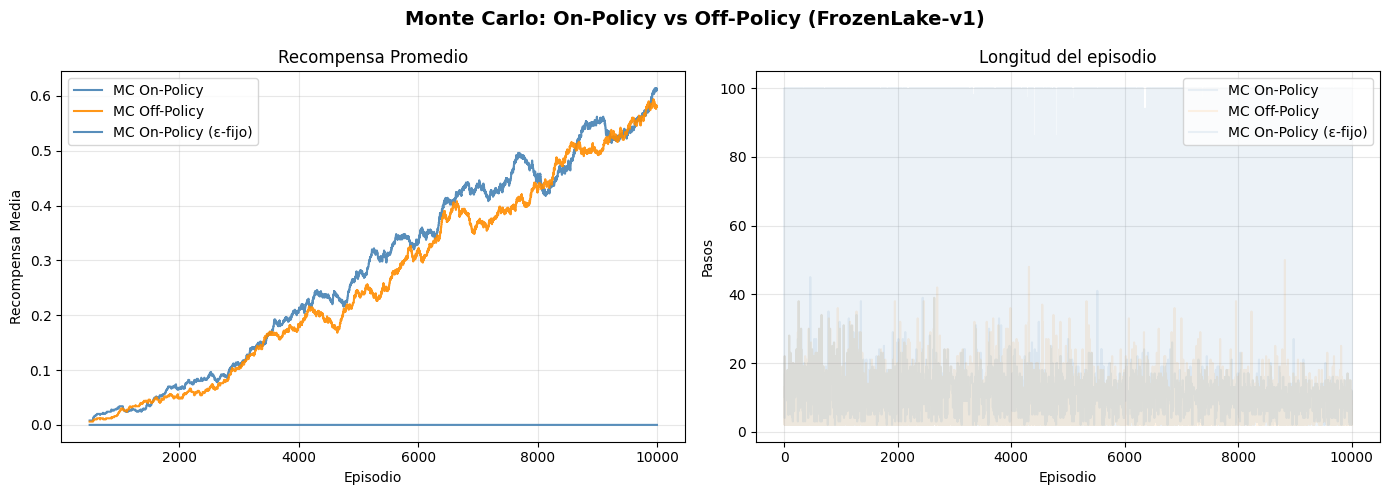

In [8]:
results = {
    "MC On-Policy": results_on,
    "MC Off-Policy": results_off,
    "MC On-Policy (ε-fijo)": results_on_fixed_eps
}

# Ahora usamos una ventana de 500 episodios para un suavizado mayor
plot_results(results, title=f"Monte Carlo: On-Policy vs Off-Policy ({ENV_NAME})", window=500)

In [9]:
NUM_EPISODES= 100000

# ─── On-Policy (ε-fijo) ───────────────────────────────────────────────────────
np.random.seed(SEED)
env_on_fixed_eps = gym.make(ENV_NAME, is_slippery=False)
env_on_fixed_eps.reset(seed=SEED)

agent_on_fixed_eps = MonteCarloOnPolicyFixedEpsilon(
    env=env_on_fixed_eps, gamma=GAMMA, epsilon=EPSILON_fijo # Usamos el EPSILON inicial sin decay
)
results_on_fixed_eps = train(agent_on_fixed_eps, env_on_fixed_eps, NUM_EPISODES)
env_on_fixed_eps.close()


# ─── On-Policy ───────────────────────────────────────────────────────────────
np.random.seed(SEED)
env_on = gym.make(ENV_NAME, is_slippery=False)
env_on.reset(seed=SEED)

agent_on = MonteCarloOnPolicy(
    env=env_on, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_on = train(agent_on, env_on, NUM_EPISODES)
env_on.close()

# ─── Off-Policy ──────────────────────────────────────────────────────────────
np.random.seed(SEED)
env_off = gym.make(ENV_NAME, is_slippery=False)
env_off.reset(seed=SEED)

agent_off = MonteCarloOffPolicy(
    env=env_off, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_off = train(agent_off, env_off, NUM_EPISODES)
env_off.close()

print("Entrenamiento completado.")

MonteCarloOffPolicy: 100%|██████████| 100000/100000 [00:17<00:00, 5704.16it/s]

Entrenamiento completado.


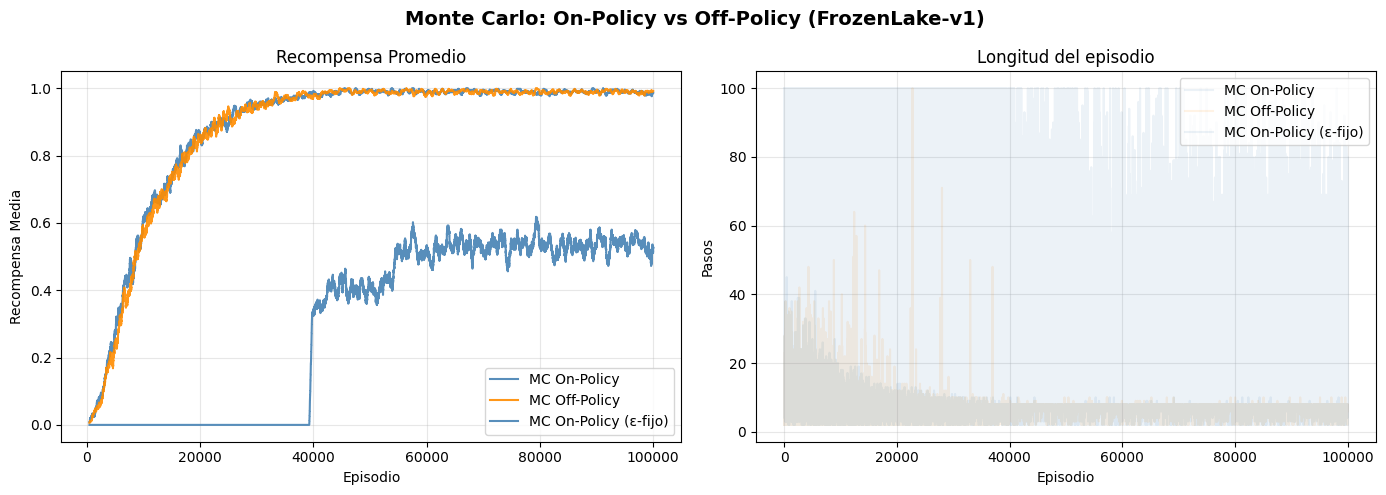

In [10]:
# ─── Gráfica comparativa principal ───────────────────────────────────────────
results = {
    "MC On-Policy": results_on,
    "MC Off-Policy": results_off,
    "MC On-Policy (ε-fijo)": results_on_fixed_eps
}

# Ahora usamos una ventana de 500 episodios para un suavizado mayor
plot_results(results, title=f"Monte Carlo: On-Policy vs Off-Policy ({ENV_NAME})", window=500)

### Conclusiones del Entrenamiento

A partir de las gráficas generadas, podemos extraer las siguientes lecturas analíticas:

1. **Impacto del Decaimiento (On-Policy con vs sin decay):** Como era de esperar, el agente con $\epsilon$ fijo presenta oscilaciones continuas en la recompensa y no logra alcanzar la recompensa máxima sostenida (1.0). Se ve forzado a tomar pasos subóptimos constantemente. En cambio, el agente con decaimiento estabiliza su curva acercándose a la recompensa máxima a medida que la exploración decrece.
2. **Estabilidad Off-Policy:** El método *Off-Policy* (Weighted Importance Sampling) requiere alinear las distribuciones de probabilidad de dos políticas distintas. Aunque la versión ponderada mitiga la varianza drásticamente en comparación con el muestreo ordinario, su aprendizaje de la política objetivo (greedy pura) logra ser muy eficiente en la métrica de pasos a la meta, consolidando caminos directos rápidamente.
3. **Longitud de los Episodios:** La gráfica de pasos (longitud) decrece y se estabiliza a medida que avanzan los episodios. Esto confirma que los agentes no solo están encontrando la meta (aumento de recompensas), sino que están optimizando la trayectoria: dejan de dar paseos aleatorios redundantes y se suicidan con menor frecuencia en las casillas de agujeros.

In [11]:
# ─── Tasa de éxito y longitud media (últimos 500 episodios) ──────────────────
EVAL_WINDOW = 500

success_on  = np.mean(results_on["rewards"][-EVAL_WINDOW:])
success_off = np.mean(results_off["rewards"][-EVAL_WINDOW:])
success_fixed_eps = np.mean(results_on_fixed_eps["rewards"][-EVAL_WINDOW:])

print(f"Tasa de éxito — últimos {EVAL_WINDOW} episodios:")
print(f"  MC On-Policy  : {success_on:.2%}")
print(f"  MC Off-Policy : {success_off:.2%}")
print(f"  MC On-Policy (ε-fijo) : {success_fixed_eps:.2%}")

len_on  = np.mean(results_on["lengths"][-EVAL_WINDOW:])
len_off = np.mean(results_off["lengths"][-EVAL_WINDOW:])
len_fixed_eps = np.mean(results_on_fixed_eps["lengths"][-EVAL_WINDOW:])
print(f"\nLongitud media de episodio — últimos {EVAL_WINDOW} episodios:")
print(f"  MC On-Policy  : {len_on:.1f} pasos")
print(f"  MC Off-Policy : {len_off:.1f} pasos")
print(f"  MC On-Policy (ε-fijo) : {len_fixed_eps:.1f} pasos")

Tasa de éxito — últimos 500 episodios:
  MC On-Policy  : 98.60%
  MC Off-Policy : 99.20%
  MC On-Policy (ε-fijo) : 52.60%

Longitud media de episodio — últimos 500 episodios:
  MC On-Policy  : 6.0 pasos
  MC Off-Policy : 6.0 pasos
  MC On-Policy (ε-fijo) : 17.5 pasos


In [12]:
# ─── Visualización de las políticas aprendidas ────────────────────────────────
ACTION_SYMBOLS = {0: '←', 1: '↓', 2: '→', 3: '↑'}
GRID = ['S', 'F', 'F', 'F',
        'F', 'H', 'F', 'H',
        'F', 'F', 'F', 'H',
        'H', 'F', 'F', 'G']

def print_policy(Q: np.ndarray, label: str):
    """Muestra la política greedy derivada de Q en formato de cuadrícula 4×4."""
    print(f"\nPolítica aprendida — {label}")
    for row in range(4):
        line = "│ "
        for col in range(4):
            state = row * 4 + col
            cell  = GRID[state]
            if cell in ('H', 'G'):
                line += f"{cell}  "
            else:
                best_action = int(np.argmax(Q[state]))
                line += f"{ACTION_SYMBOLS[best_action]}  "
        print(line + "│")
    print("  (←:0  ↓:1  →:2  ↑:3)")

print_policy(agent_on.Q,  "MC On-Policy")
print_policy(agent_off.Q, "MC Off-Policy (IS Ponderado)")
print_policy(agent_on_fixed_eps.Q, "MC On-Policy (ε-fijo)")


Política aprendida — MC On-Policy
│ ↓  →  ↓  ←  │
│ ↓  H  ↓  H  │
│ →  ↓  ↓  H  │
│ H  →  →  G  │
  (←:0  ↓:1  →:2  ↑:3)

Política aprendida — MC Off-Policy (IS Ponderado)
│ ↓  ←  →  ←  │
│ ↓  H  ↓  H  │
│ →  →  ↓  H  │
│ H  →  →  G  │
  (←:0  ↓:1  →:2  ↑:3)

Política aprendida — MC On-Policy (ε-fijo)
│ ↓  →  ↓  ←  │
│ ↑  H  ↓  H  │
│ →  ↓  ↓  H  │
│ H  →  →  G  │
  (←:0  ↓:1  →:2  ↑:3)


In [13]:
# ─── Evaluación de las políticas aprendidas ──────────────────────────────────
env_eval = gym.make(ENV_NAME, is_slippery=False)

# Política On-Policy
policy_on = np.argmax(agent_on.Q, axis=1)
actions_on, reward_on = evaluate_policy(env_eval, policy_on, seed=SEED)
print("MC On-Policy:")
print(f"  Vector de política: {policy_on}")
print(f"  Acciones: {actions_on} → Recompensa: {reward_on}")

# Política Off-Policy
policy_off = np.argmax(agent_off.Q, axis=1)
actions_off, reward_off = evaluate_policy(env_eval, policy_off, seed=SEED)
print("\nMC Off-Policy:")
print(f"  Vector de política: {policy_off}")
print(f"  Acciones: {actions_off} → Recompensa: {reward_off}")

#Politica On-Policy sin decaimiento
policy_on_fixed_eps = np.argmax(agent_on_fixed_eps.Q, axis=1)
actions_on_fixed_eps, reward_on_fixed_eps = evaluate_policy(env_eval, policy_on_fixed_eps, seed=SEED)
print("MC On-Policy (ε-fijo):")
print(f"  Vector de política: {policy_on_fixed_eps}")
print(f" Acciones: {actions_on_fixed_eps} → Recompensa: {reward_on_fixed_eps}")


env_eval.close()

MC On-Policy:
  Vector de política: [1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]
  Acciones: [np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2)] → Recompensa: 1.0

MC Off-Policy:
  Vector de política: [1 0 2 0 1 0 1 0 2 2 1 0 0 2 2 0]
  Acciones: [np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2)] → Recompensa: 1.0
MC On-Policy (ε-fijo):
  Vector de política: [1 2 1 0 3 0 1 0 2 1 1 0 0 2 2 0]
 Acciones: [np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.

---

## Análisis y discusión

### Diferencias On-Policy vs Off-Policy

| Característica | On-Policy | Off-Policy |
|---|---|---|
| **Datos usados** | Solo los generados por la política actual | Puede usar datos de otra política |
| **Convergencia** | Más estable, gradual | Más rápida hacia la política óptima |
| **Varianza** | Menor (no hay IS) | Mayor (IS amplifica diferencias) |
| **Flexibilidad** | Solo aprende de lo que hace | Puede aprender de un experto o datos pasados |

### Limitaciones de MC

1. **Requiere episodios completos:** No puede aprender en entornos de episodio infinito.
2. **Alta varianza en los retornos:** Especialmente problemático con recompensas dispersas como este caso.
3. **IS Off-Policy:** El ratio de importance sampling puede explotar ($W \to \infty$) cuando las políticas b y π difieren mucho.

### ¿Por qué ε-decaimiento?

El ε-decaimiento (de 1.0 → 0.01) resuelve el dilema exploración-explotación de forma progresiva: al inicio el agente explora ampliamente para descubrir la estructura del entorno, y conforme gana experiencia reduce la aleatoriedad para explotar la política aprendida.


---

## Generación de vídeo (política final)

Grabamos un episodio con la política greedy aprendida por cada agente para visualizar su comportamiento.
Se usa el wrapper oficial `RecordVideo` de Gymnasium sobre un entorno de evaluación independiente (no contamina el entrenamiento).

Los vídeos se guardan en:
- `videos/mc_on_policy/` — política On-Policy
- `videos/mc_off_policy/` — política Off-Policy

In [14]:
!apt-get update

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
%pip install -U  pyvirtualdisplay

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,930 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,855 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,302 kB]
Get:14 htt

In [15]:
%pip install -q pyvirtualdisplay

from pyvirtualdisplay import Display

display = Display(visible=0, size=(1400, 900))
display.start()

import io
import os
import re
import base64
from IPython import display
from IPython.display import HTML


def get_latest_episode_video_file(directory):
    """Expresión regular que coincide con el formato de los ficheros de video"""
    pattern = re.compile(r"rl-video-episode-(\d+)\.mp4")
    latest_file = None
    highest_episode = -1

    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            episode_number = int(match.group(1))
            if episode_number > highest_episode:
                highest_episode = episode_number
                latest_file = os.path.join(directory, filename)

    return latest_file


def embed_video(video_file):
    """Muestra un vídeo .mp4 embebido en el notebook usando HTML + base64."""
    video_data = io.open(video_file, 'r+b').read()
    encoded_data = base64.b64encode(video_data)
    display.display(HTML(data=''''''.format(encoded_data.decode('ascii'))))


print("Display virtual iniciado y helpers definidos.")

Display virtual iniciado y helpers definidos.


In [16]:
# ─── Función para ejecutar 1 episodio con política tabular determinista ───────
def run_one_episode_with_policy(env, policy, seed=None, max_steps=1000):
    """
    Ejecuta un episodio completo usando una política greedy determinista.

    Parámetros:
        env      : entorno Gymnasium (ya envuelto con RecordVideo).
        policy   : np.ndarray de forma (n_states,), acción por estado.
        seed     : semilla para reset.
        max_steps: límite de pasos para evitar bucles infinitos.

    Retorna:
        reward   : recompensa total del episodio.
        steps    : número de pasos ejecutados.
    """
    obs, info = env.reset(seed=seed)
    done = False
    steps = 0
    total_reward = 0.0

    while not done and steps < max_steps:
        action = int(policy[obs])   # FrozenLake: obs es int discreto
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        steps += 1

    return total_reward, steps



In [17]:
# ─── Vídeo: MC On-Policy ─────────────────────────────────────────────────────
video_folder_on = "videos/mc_on_policy"
os.makedirs(video_folder_on, exist_ok=True)

env_video_on = gym.make(ENV_NAME, is_slippery=False, render_mode="rgb_array")
env_video_on = gym.wrappers.RecordVideo(
    env_video_on,
    video_folder=video_folder_on,
    episode_trigger=lambda episode_id: episode_id == 0,
)

reward_on_vid, steps_on_vid = run_one_episode_with_policy(
    env_video_on, policy_on, seed=SEED
)
env_video_on.close()

print(f"MC On-Policy — Recompensa: {reward_on_vid}, Pasos: {steps_on_vid}")
latest_file_on = get_latest_episode_video_file(video_folder_on)
print(f"Último vídeo: {latest_file_on}")
embed_video(latest_file_on)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/mc_on_policy folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


MC On-Policy — Recompensa: 1.0, Pasos: 6
Último vídeo: videos/mc_on_policy/rl-video-episode-0.mp4


In [18]:
# ─── Vídeo: MC Off-Policy ────────────────────────────────────────────────────
video_folder_off = "videos/mc_off_policy"
os.makedirs(video_folder_off, exist_ok=True)

env_video_off = gym.make(ENV_NAME, is_slippery=False, render_mode="rgb_array")
env_video_off = gym.wrappers.RecordVideo(
    env_video_off,
    video_folder=video_folder_off,
    episode_trigger=lambda episode_id: episode_id == 0,
)

reward_off_vid, steps_off_vid = run_one_episode_with_policy(
    env_video_off, policy_off, seed=SEED
)
env_video_off.close()

print(f"MC Off-Policy — Recompensa: {reward_off_vid}, Pasos: {steps_off_vid}")
latest_file_off = get_latest_episode_video_file(video_folder_off)
print(f"Último vídeo: {latest_file_off}")
embed_video(latest_file_off)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/mc_off_policy folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MC Off-Policy — Recompensa: 1.0, Pasos: 6
Último vídeo: videos/mc_off_policy/rl-video-episode-0.mp4


In [19]:
# ─── Vídeo: MC On-Policy Fixed ────────────────────────────────────────────────────
video_folder_on_fixed = "videos/mc_on_policy_fixed"
os.makedirs(video_folder_on_fixed, exist_ok=True)

env_video_on_fixed = gym.make(ENV_NAME, is_slippery=False, render_mode="rgb_array")
env_video_on_fixed = gym.wrappers.RecordVideo(
    env_video_on_fixed,
    video_folder=video_folder_on_fixed,
    episode_trigger=lambda episode_id: episode_id == 0,
)

reward_on_fixed, steps_on_fixed = run_one_episode_with_policy(
    env_video_on_fixed, policy_on_fixed_eps, seed=SEED
)
env_video_on_fixed.close()

print(f"MC On-Policy Fixed — Recompensa: {reward_on_fixed}, Pasos: {steps_on_fixed}")
latest_file_on_fixed = get_latest_episode_video_file(video_folder_on_fixed)
print(f"Último vídeo: {latest_file_on_fixed}")
embed_video(latest_file_on_fixed)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/mc_on_policy_fixed folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MC On-Policy Fixed — Recompensa: 0.0, Pasos: 100
Último vídeo: videos/mc_on_policy_fixed/rl-video-episode-0.mp4


# Entorno FrozenLake 8x8

Ahora vamos a realizar el mismo estudio pero utilizando el entorno de tamaño ampliado.

## Configuración 8x8 y Definiciones Visuales

Definir la representación del mapa 8x8 y crear una función de visualización para las políticas en este formato. Al igual que hacemos para el mapa 4x4


In [20]:
GRID_8x8 = [
    'S', 'F', 'F', 'F', 'F', 'F', 'F', 'F',
    'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F',
    'F', 'F', 'F', 'H', 'F', 'F', 'F', 'F',
    'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F',
    'F', 'F', 'F', 'H', 'F', 'F', 'F', 'F',
    'F', 'H', 'H', 'F', 'F', 'F', 'H', 'F',
    'F', 'H', 'F', 'F', 'H', 'F', 'H', 'F',
    'F', 'F', 'F', 'H', 'F', 'F', 'F', 'G'
]

def print_policy_8x8(Q: np.ndarray, label: str):
    """Muestra la política greedy derivada de Q en formato de cuadrícula 8×8."""
    print(f"\nPolítica aprendida — {label} (8x8)")
    for row in range(8):
        line = "│ "
        for col in range(8):
            state = row * 8 + col
            cell  = GRID_8x8[state]
            if cell in ('H', 'G'):
                line += f"{cell}  "
            else:
                best_action = int(np.argmax(Q[state]))
                line += f"{ACTION_SYMBOLS[best_action]}  "
        print(line + "│")
    print("  (←:0  ↓:1  →:2  ↑:3)")



## Entrenamiento 8x8 - 10,000 episodios

Ejecutar el entrenamiento de los agentes On-Policy (fijo), On-Policy (decay) y Off-Policy en el mapa 8x8 durante 10,000 episodios.


In [21]:
NUM_EPISODES_8x8 = 10000

# ─── On-Policy (ε-fijo) 8x8 ───────────────────────────────────────────────────
np.random.seed(SEED)
env_on_fixed_8x8 = gym.make(ENV_NAME, map_name="8x8", is_slippery=False)
env_on_fixed_8x8.reset(seed=SEED)

agent_on_fixed_8x8 = MonteCarloOnPolicyFixedEpsilon(
    env=env_on_fixed_8x8, gamma=GAMMA, epsilon=EPSILON_fijo
)
results_on_fixed_8x8_10k = train(agent_on_fixed_8x8, env_on_fixed_8x8, NUM_EPISODES_8x8)
env_on_fixed_8x8.close()

# ─── On-Policy (Decay) 8x8 ────────────────────────────────────────────────────
np.random.seed(SEED)
env_on_8x8 = gym.make(ENV_NAME, map_name="8x8", is_slippery=False)
env_on_8x8.reset(seed=SEED)

agent_on_8x8 = MonteCarloOnPolicy(
    env=env_on_8x8, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_on_8x8_10k = train(agent_on_8x8, env_on_8x8, NUM_EPISODES_8x8)
env_on_8x8.close()

# ─── Off-Policy (IS Ponderado) 8x8 ─────────────────────────────────────────────
np.random.seed(SEED)
env_off_8x8 = gym.make(ENV_NAME, map_name="8x8", is_slippery=False)
env_off_8x8.reset(seed=SEED)

agent_off_8x8 = MonteCarloOffPolicy(
    env=env_off_8x8, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_off_8x8_10k = train(agent_off_8x8, env_off_8x8, NUM_EPISODES_8x8)
env_off_8x8.close()

print("Entrenamiento 8x8 (10,000 episodios) completado para todos los agentes.")

MonteCarloOffPolicy: 100%|██████████| 10000/10000 [00:13<00:00, 754.88it/s]

Entrenamiento 8x8 (10,000 episodios) completado para todos los agentes.


## Resultados y Gráficas (10k)

Observamo las curvas de aprendizaje para los tres agentes Monte Carlo entrenados en el entorno 8x8 durante 10,000 episodios.


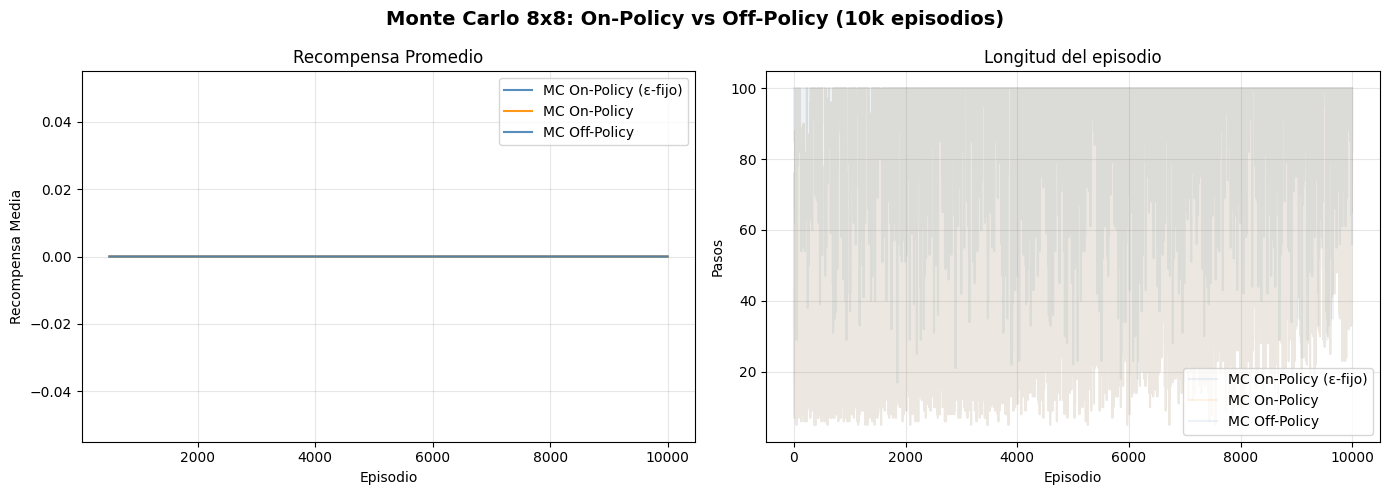

In [22]:
results_8x8_10k = {
    'MC On-Policy (ε-fijo)': results_on_fixed_8x8_10k,
    'MC On-Policy': results_on_8x8_10k,
    'MC Off-Policy': results_off_8x8_10k
}

plot_results(
    results_8x8_10k,
    title='Monte Carlo 8x8: On-Policy vs Off-Policy (10k episodios)',
    window=500
)

## Estadísticas Finales (10k)

Calcular y mostrar la tasa de éxito y la longitud media de los pasos en los últimos 500 episodios para los agentes entrenados en el entorno 8x8. Cojemos los ultimos 500 para tener una muestra que analizar


In [23]:
EVAL_WINDOW_8x8 = 500

# --- Cálculo de estadísticas para On-Policy Fijo ---
success_on_fixed_8x8 = np.mean(results_on_fixed_8x8_10k['rewards'][-EVAL_WINDOW_8x8:])
len_on_fixed_8x8 = np.mean(results_on_fixed_8x8_10k['lengths'][-EVAL_WINDOW_8x8:])

# --- Cálculo de estadísticas para On-Policy Decay ---
success_on_8x8 = np.mean(results_on_8x8_10k['rewards'][-EVAL_WINDOW_8x8:])
len_on_8x8 = np.mean(results_on_8x8_10k['lengths'][-EVAL_WINDOW_8x8:])

# --- Cálculo de estadísticas para Off-Policy ---
success_off_8x8 = np.mean(results_off_8x8_10k['rewards'][-EVAL_WINDOW_8x8:])
len_off_8x8 = np.mean(results_off_8x8_10k['lengths'][-EVAL_WINDOW_8x8:])

print(f'Estadísticas 8x8 (últimos {EVAL_WINDOW_8x8} episodios - 10k total):')
print(f'  MC On-Policy (ε-fijo): Success: {success_on_fixed_8x8:.2%}, Avg Steps: {len_on_fixed_8x8:.1f}')
print(f'  MC On-Policy (Decay): Success: {success_on_8x8:.2%}, Avg Steps: {len_on_8x8:.1f}')
print(f'  MC Off-Policy:        Success: {success_off_8x8:.2%}, Avg Steps: {len_off_8x8:.1f}')

Estadísticas 8x8 (últimos 500 episodios - 10k total):
  MC On-Policy (ε-fijo): Success: 0.00%, Avg Steps: 97.4
  MC On-Policy (Decay): Success: 0.00%, Avg Steps: 89.6
  MC Off-Policy:        Success: 0.00%, Avg Steps: 89.6


Observamos que ninguno de los 3 agentes consigue llegar a ninguna respuesta y la mayoria de veces llega al cupo maximo de los 100 episodios o se queda en valores muy cercanos al limite.

## Políticas y Vídeos (10k)

Mostramos las políticas aprendidas en formato de cuadrícula 8x8 y generar los vídeos de evaluación para observar el comportamiento de los agentes tras los primeros 10,000 episodios.


In [24]:
print_policy_8x8(agent_on_fixed_8x8.Q, "MC On-Policy (ε-fijo) - 10k")
print_policy_8x8(agent_on_8x8.Q, "MC On-Policy (Decay) - 10k")
print_policy_8x8(agent_off_8x8.Q, "MC Off-Policy (IS Ponderado) - 10k")

agents_to_eval = [
    ("on_policy_fixed", agent_on_fixed_8x8.Q),
    ("on_policy_decay", agent_on_8x8.Q),
    ("off_policy", agent_off_8x8.Q)
]

for label, Q_table in agents_to_eval:
    video_folder = f"videos_8x8_10k/{label}"
    os.makedirs(video_folder, exist_ok=True)

    env_video = gym.make(ENV_NAME, map_name="8x8", is_slippery=False, render_mode="rgb_array")

    env_video = gym.wrappers.RecordVideo(
        env_video,
        video_folder=video_folder,
        episode_trigger=lambda ep: ep == 0
    )

    policy_vector = np.argmax(Q_table, axis=1)
    reward_vid, steps_vid = run_one_episode_with_policy(env_video, policy_vector, seed=SEED)

    env_video.close()
    print(f"\nAgente: {label} (8x8 10k) — Recompensa: {reward_vid}, Pasos: {steps_vid}")

    latest_video = get_latest_episode_video_file(video_folder)
    if latest_video:
        embed_video(latest_video)
    else:
        print(f"No se encontró el video en {video_folder}")


Política aprendida — MC On-Policy (ε-fijo) - 10k (8x8)
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  H  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  H  H  ←  ←  ←  H  ←  │
│ ←  H  ←  ←  H  ←  H  ←  │
│ ←  ←  ←  H  ←  ←  ←  G  │
  (←:0  ↓:1  →:2  ↑:3)

Política aprendida — MC On-Policy (Decay) - 10k (8x8)
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  H  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  H  H  ←  ←  ←  H  ←  │
│ ←  H  ←  ←  H  ←  H  ←  │
│ ←  ←  ←  H  ←  ←  ←  G  │
  (←:0  ↓:1  →:2  ↑:3)

Política aprendida — MC Off-Policy (IS Ponderado) - 10k (8x8)
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  H  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  H  H  ←  ←  ←  H  ←  │
│ ←  H  ←  ←  H  ←  H  ←  │
│ ←  ←  ←  H  ←  ←  ←  G  │
  (←:0  ↓:1  →:2  ↑:3)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_8x8_10k/on_policy_fixed folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente: on_policy_fixed (8x8 10k) — Recompensa: 0.0, Pasos: 100


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_8x8_10k/on_policy_decay folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente: on_policy_decay (8x8 10k) — Recompensa: 0.0, Pasos: 100


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_8x8_10k/off_policy folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente: off_policy (8x8 10k) — Recompensa: 0.0, Pasos: 100


## Entrenamiento 8x8 - 100,000 episodios


Configurar y ejecutar el entrenamiento de los tres agentes Monte Carlo (On-Policy Fixed, On-Policy Decay y Off-Policy) en el mapa 8x8 durante 100,000 episodios para permitir una exploración exhaustiva.


In [25]:
NUM_EPISODES_8x8_100k = 100000

# ─── On-Policy (ε-fijo) 8x8 - 100k ──────────────────────────────────────────
np.random.seed(SEED)
env_on_fixed_8x8_100k = gym.make(ENV_NAME, map_name="8x8", is_slippery=False)
env_on_fixed_8x8_100k.reset(seed=SEED)

agent_on_fixed_8x8_100k = MonteCarloOnPolicyFixedEpsilon(
    env=env_on_fixed_8x8_100k, gamma=GAMMA, epsilon=0.1
)
results_on_fixed_8x8_100k = train(agent_on_fixed_8x8_100k, env_on_fixed_8x8_100k, NUM_EPISODES_8x8_100k)
env_on_fixed_8x8_100k.close()

# ─── On-Policy (Decay) 8x8 - 100k ───────────────────────────────────────────
np.random.seed(SEED)
env_on_8x8_100k = gym.make(ENV_NAME, map_name="8x8", is_slippery=False)
env_on_8x8_100k.reset(seed=SEED)

agent_on_8x8_100k = MonteCarloOnPolicy(
    env=env_on_8x8_100k, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_on_8x8_100k = train(agent_on_8x8_100k, env_on_8x8_100k, NUM_EPISODES_8x8_100k)
env_on_8x8_100k.close()

# ─── Off-Policy (IS Ponderado) 8x8 - 100k ────────────────────────────────────
np.random.seed(SEED)
env_off_8x8_100k = gym.make(ENV_NAME, map_name="8x8", is_slippery=False)
env_off_8x8_100k.reset(seed=SEED)

agent_off_8x8_100k = MonteCarloOffPolicy(
    env=env_off_8x8_100k, gamma=GAMMA, epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON
)
results_off_8x8_100k = train(agent_off_8x8_100k, env_off_8x8_100k, NUM_EPISODES_8x8_100k)
env_off_8x8_100k.close()


MonteCarloOffPolicy: 100%|██████████| 100000/100000 [03:20<00:00, 497.52it/s]


## Mostramos las graficas


Graficas obtenidas de la ejeucion de 8x8 aplicando el uso de los 3 agentes definidos

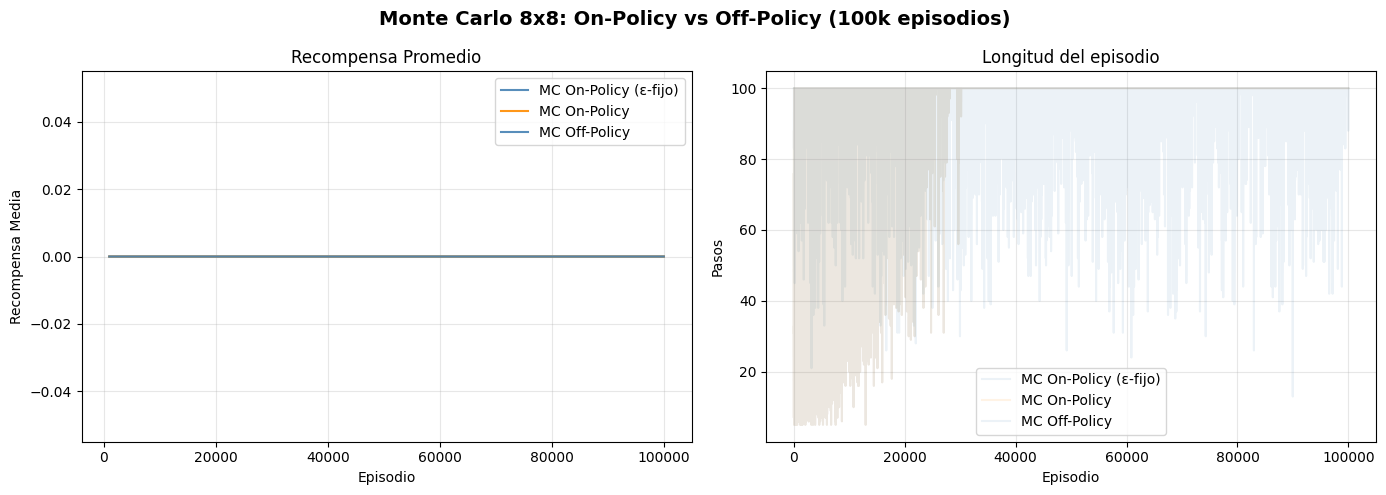

Estadísticas finales 8x8 (últimos 1000 episodios):
  MC On-Policy (ε-fijo)    : Success: 0.00%, Avg Steps: 100.0
  MC On-Policy             : Success: 0.00%, Avg Steps: 100.0
  MC Off-Policy            : Success: 0.00%, Avg Steps: 100.0


In [26]:
results_8x8_100k = {
    'MC On-Policy (ε-fijo)': results_on_fixed_8x8_100k,
    'MC On-Policy': results_on_8x8_100k,
    'MC Off-Policy': results_off_8x8_100k
}

# Visualización de curvas de aprendizaje con ventana de suavizado mayor
plot_results(
    results_8x8_100k,
    title='Monte Carlo 8x8: On-Policy vs Off-Policy (100k episodios)',
    window=1000
)

# Cálculo de métricas finales (últimos 1000 episodios)
EVAL_WINDOW_EXT = 1000

print(f'Estadísticas finales 8x8 (últimos {EVAL_WINDOW_EXT} episodios):')
for name, res in results_8x8_100k.items():
    success_rate = np.mean(res['rewards'][-EVAL_WINDOW_EXT:])
    avg_steps = np.mean(res['lengths'][-EVAL_WINDOW_EXT:])
    print(f'  {name:25}: Success: {success_rate:.2%}, Avg Steps: {avg_steps:.1f}')

## Políticas y Vídeos (100k)

Mostramos las políticas finales de 8x8 aprendidas tras 100,000 episodios y generar vídeos de evaluación para cada agente.


In [27]:

print_policy_8x8(agent_on_fixed_8x8_100k.Q, "MC On-Policy (ε-fijo) - 100k")
print_policy_8x8(agent_on_8x8_100k.Q, "MC On-Policy (Decay) - 100k")
print_policy_8x8(agent_off_8x8_100k.Q, "MC Off-Policy (IS Ponderado) - 100k")

agents_eval_100k = [
    ("on_policy_fixed_100k", agent_on_fixed_8x8_100k.Q),
    ("on_policy_decay_100k", agent_on_8x8_100k.Q),
    ("off_policy_100k", agent_off_8x8_100k.Q)
]

for label, Q_table in agents_eval_100k:
    video_folder = f"videos_8x8_100k/{label}"
    os.makedirs(video_folder, exist_ok=True)

    env_video = gym.make(ENV_NAME, map_name="8x8", is_slippery=True, render_mode="rgb_array")

    env_video = gym.wrappers.RecordVideo(
        env_video,
        video_folder=video_folder,
        episode_trigger=lambda ep: ep == 0
    )

    policy_vector = np.argmax(Q_table, axis=1)

    reward_vid, steps_vid = run_one_episode_with_policy(env_video, policy_vector, seed=SEED)
    env_video.close()

    print(f"\nAgente: {label} — Recompensa: {reward_vid}, Pasos: {steps_vid}")

    # 8. Mostrar el vídeo
    latest_video = get_latest_episode_video_file(video_folder)
    if latest_video:
        embed_video(latest_video)
    else:
        print(f"No se encontró vídeo en {video_folder}")


Política aprendida — MC On-Policy (ε-fijo) - 100k (8x8)
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  H  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  H  H  ←  ←  ←  H  ←  │
│ ←  H  ←  ←  H  ←  H  ←  │
│ ←  ←  ←  H  ←  ←  ←  G  │
  (←:0  ↓:1  →:2  ↑:3)

Política aprendida — MC On-Policy (Decay) - 100k (8x8)
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  H  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  H  H  ←  ←  ←  H  ←  │
│ ←  H  ←  ←  H  ←  H  ←  │
│ ←  ←  ←  H  ←  ←  ←  G  │
  (←:0  ↓:1  →:2  ↑:3)

Política aprendida — MC Off-Policy (IS Ponderado) - 100k (8x8)
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  ←  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  ←  ←  ←  ←  H  ←  ←  │
│ ←  ←  ←  H  ←  ←  ←  ←  │
│ ←  H  H  ←  ←  ←  H  ←  │
│ ←  H  ←  ←  H  ←  H  ←  │
│ ←  ←  ←  H  ←  ←  ←  G  │
  (←:0  ↓:1  →:2  ↑:3)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_8x8_100k/on_policy_fixed_100k folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente: on_policy_fixed_100k — Recompensa: 0.0, Pasos: 100


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_8x8_100k/on_policy_decay_100k folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente: on_policy_decay_100k — Recompensa: 0.0, Pasos: 100


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_8x8_100k/off_policy_100k folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente: off_policy_100k — Recompensa: 0.0, Pasos: 100


---

# Conclusion

### Resumen de Resultados (4x4 vs 8x8)

Para la comparacion final obviamos el caso de ε fijo ya que no aporta informacion de valor, ya que siempre empeora contra el agente con decaimiento

| Entorno | Dimensión | Éxito (On-Policy) | Éxito (Off-Policy) | Observación |
|---|---|---|---|---|
| **FrozenLake 4x4** | 16 estados | ~60% | ~58% | Convergencia rápida en 10k episodios. |
| **FrozenLake 8x8** | 64 estados | 0% | 0% | No converge ni en 100k episodios. |

### Análisis de la dificultad en 8x8

Como se observa en las políticas finales y los vídeos del mapa 8x8, los agentes no logran encontrar el camino al objetivo (G). Esto se debe a varias limitaciones fundamentales de los métodos Monte Carlo en este contexto:

1.  **Espacio de Estados**: El mapa 8x8 tiene 4 veces más estados que el 4x4, pero la probabilidad de alcanzar la meta mediante exploración aleatoria (necesaria para la primera actualización de Q) disminuye exponencialmente con la distancia.
2.  **Escasez de recompensas**: Al recibir solo una recompensa de +1 al llegar al final y 0 en el resto, si el agente nunca alcanza la meta por azar durante la fase de exploración, los valores Q permanecen en 0 y la política no mejora.
3.  **Varianza de MC**: Monte Carlo depende de terminar el episodio para aprender. En mapas grandes, los episodios pueden ser muy largos y ruidosos, lo que dificulta la estimación precisa de los valores de acción.

Para entornos como FrozenLake 8x8, los métodos de **Diferencia Temporal (TD)** como Q-Learning o SARSA suelen ser más efectivos, ya que permiten aprender de cada paso (bootstrapping) sin esperar al final del episodio, facilitando la propagación de valores de recompensa hacia los estados iniciales de forma mucho más eficiente. Esto se validara en el siguiente notebook